# TOP 10 HIGHEST PAID SKILLS FOR D.A.


In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
def clean_list (skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
df['job_skills'] = df['job_skills'].apply(clean_list)

In [2]:
df_da = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()

In [3]:
df_da.head(2)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
36,Data Analyst,Data Analyst,"Des Moines, IA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-11-06 13:01:22,False,True,United States,NaN,NaN,NaN,Assuredpartners,None,NaN
68,Data Analyst,Sr. Research Data Analyst,"Baltimore, MD",via ZipRecruiter,Full-time,False,"New York, United States",2023-03-24 13:01:00,False,False,United States,NaN,NaN,NaN,Johns Hopkins Medicine,"[r, zoom]","{'programming': ['r'], 'sync': ['zoom']}"


In [4]:
df_explode_da = df_da.explode('job_skills')

In [5]:
df_explode_da.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
36,Data Analyst,Data Analyst,"Des Moines, IA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-11-06 13:01:22,False,True,United States,NaN,NaN,NaN,Assuredpartners,None,NaN
68,Data Analyst,Sr. Research Data Analyst,"Baltimore, MD",via ZipRecruiter,Full-time,False,"New York, United States",2023-03-24 13:01:00,False,False,United States,NaN,NaN,NaN,Johns Hopkins Medicine,r,"{'programming': ['r'], 'sync': ['zoom']}"
68,Data Analyst,Sr. Research Data Analyst,"Baltimore, MD",via ZipRecruiter,Full-time,False,"New York, United States",2023-03-24 13:01:00,False,False,United States,NaN,NaN,NaN,Johns Hopkins Medicine,zoom,"{'programming': ['r'], 'sync': ['zoom']}"


In [6]:
df_explode_da = df_explode_da.dropna(subset='salary_year_avg')

In [7]:
Highest_paid_skills = df_explode_da.pivot_table(index='job_skills', values='salary_year_avg', aggfunc='median').sort_values('salary_year_avg', ascending=False).head(10)

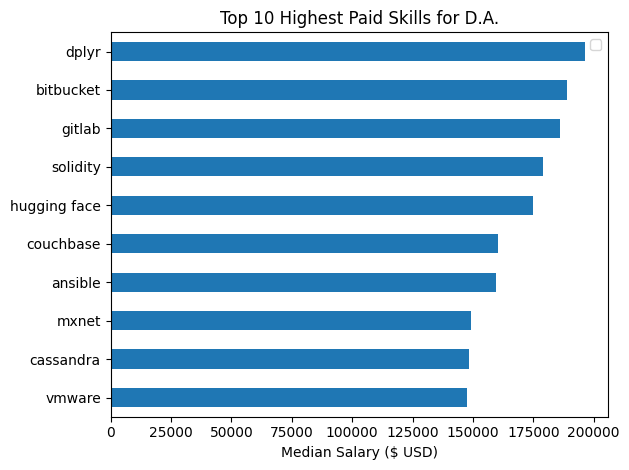

In [8]:
Highest_paid_skills.plot(kind='barh')
plt.gca().invert_yaxis()

plt.title('Top 10 Highest Paid Skills for D.A.')
plt.xlabel('Median Salary ($ USD)')
plt.ylabel('')
plt.tight_layout()
plt.legend('')
plt.show()

In [9]:
df_da['job_skills'].mode()

0    [excel]
Name: job_skills, dtype: object

In [11]:
top_10_skills2 = df_explode_da['job_skills'].value_counts().head(10)

In [12]:
type(top_10_skills2)

pandas.core.series.Series

In [13]:
top_10_skills2 = top_10_skills2.reset_index()
top_10_skills2.columns = ['Skill', 'Count']

In [15]:
top_10_skills2.head(10)

,Skill,Count
0,sql,2508
1,excel,1808
2,python,1431
3,tableau,1364
4,sas,926
5,r,893
6,power bi,838
7,powerpoint,462
8,word,461
9,sql server,286


Text(0.5, 1.0, 'Top 10 Most In-Demand Skills for D.A.')

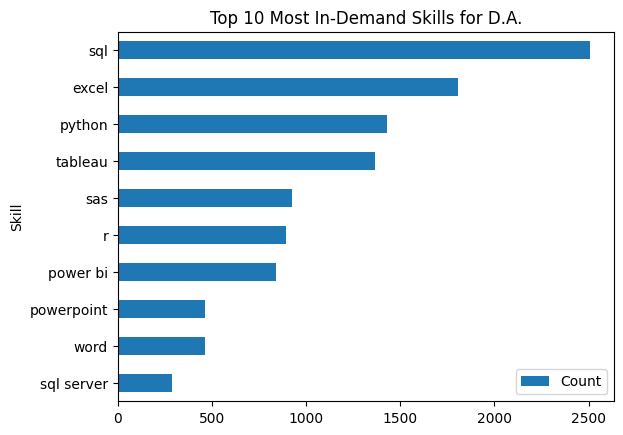

In [23]:
top_10_skills2.plot(kind ='barh', x='Skill', y='Count')
plt.gca().invert_yaxis()
plt.title('Top 10 Most In-Demand Skills for D.A.')

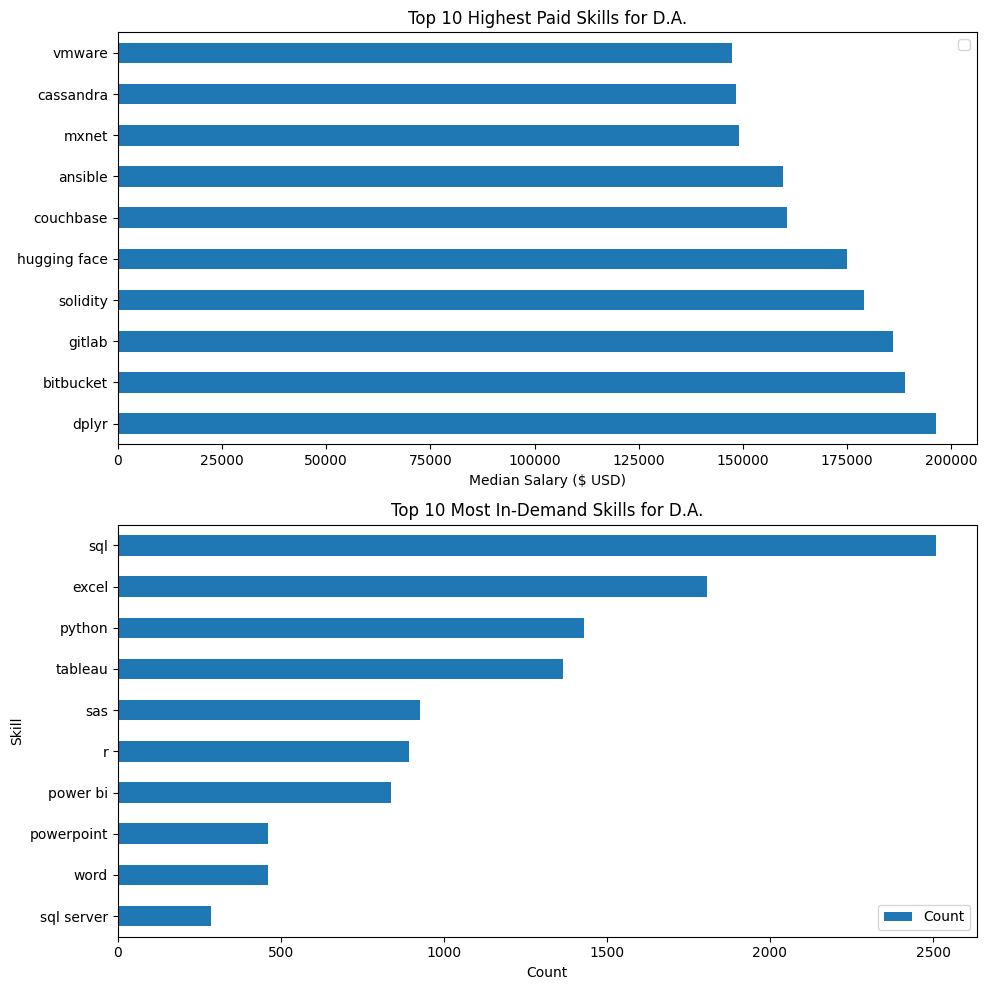

In [37]:


fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# --- Primer gráfico (ax[0]) ---
Highest_paid_skills.plot(kind='barh', ax=ax[0])
ax[0].set_title('Top 10 Highest Paid Skills for D.A.')
ax[0].set_xlabel('Median Salary ($ USD)')
ax[0].set_ylabel('')
ax[0].legend([])  # Quita la leyenda

# --- Segundo gráfico (ax[1]) ---
top_10_skills2.plot(kind='barh', x='Skill', y='Count', ax=ax[1])
ax[1].invert_yaxis()
ax[1].set_title('Top 10 Most In-Demand Skills for D.A.')
ax[1].set_xlabel('Count')
ax[1].set_ylabel('Skill')

# Ajusta el espaciado para que los títulos y etiquetas no se solapen
plt.tight_layout()
plt.show()